In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
from generator import Generator
from detector.canny_detect import CannyDetect
from PIL import Image
import json
from tqdm import tqdm
import torch
from utils import get_mask_ori, get_mask_ref, down_size
from image_gen_aux import DepthPreprocessor
from controlnet_aux import CannyDetector
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from utils import down_size

In [3]:
base_model = 'black-forest-labs/FLUX.1-dev'
control_model = '/amax/hchuz/hfd_models/FLUX.1-dev-ControlNet-Union-Pro'
#control_model = '/amax/hchuz/hfd_models/FLUX.1-Depth-dev-lora'
#control_model = '/amax/hchuz/hfd_models/FLUX.1-Canny-dev-lora'
flux_redux = 'black-forest-labs/FLUX.1-Redux-dev'
#flux_fill = '/amax/hchuz/hfd_models/FLUX.1-Fill-dev'
flux_fill = None
dino_checkpoint = None
sam_checkpoint = None
lora_weights = None
offload = True

In [4]:
generator = Generator(base_model, control_model, flux_redux, dino_checkpoint, sam_checkpoint, offload, flux_fill=flux_fill, lora_weights=lora_weights)
#processor = DepthPreprocessor.from_pretrained("/amax/hchuz/hfd_models/depth-anything-large-hf").to('cuda')
#processor = CannyDetector()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/3 [00:00<?, ?it/s]

In [5]:
cannydetect = CannyDetect()

In [ ]:
# box
img_root = '/amax/hchuz/architectural_heritage/data/boundingbox'
ann = pd.read_csv('/amax/hchuz/architectural_heritage/data/boundingbox/labels_my-project-name_2025-03-25-04-32-06.csv')
name = list(set(ann.image_name))[1]
global_style_image = Image.open(os.path.join(img_root, name)).convert("RGB")
control_image = np.zeros((global_style_image.height, global_style_image.width, 3), dtype=np.uint8)
img_vis = np.array(global_style_image)
for box in ann[ann.image_name == name][['bbox_x', 'bbox_y', 'bbox_width', 'bbox_height']].to_numpy():
    x1,y1,x2,y2 = box[0], box[1], box[0]+box[2], box[1]+box[3]
    cv2.rectangle(control_image, (x1,y1), (x2, y2), (255,255,255), thickness=1)
    cv2.rectangle(img_vis, (x1,y1), (x2, y2), (255,0,0), thickness=1)
control_image = cannydetect.det_canny(control_image)
Image.fromarray(control_image)

In [ ]:
# img_path = '/amax/hchuz/architectural_heritage/相似的几个2/Snipaste_2023-02-21_13-32-42.png'
# global_style_image = Image.open(img_path).convert('RGB')
# with open(img_path.replace('.png', '.json'), 'r') as f:
#     data = json.load(f)
# control_image = cannydetect.polygon2canny([sample['points'] for sample in data['shapes']])

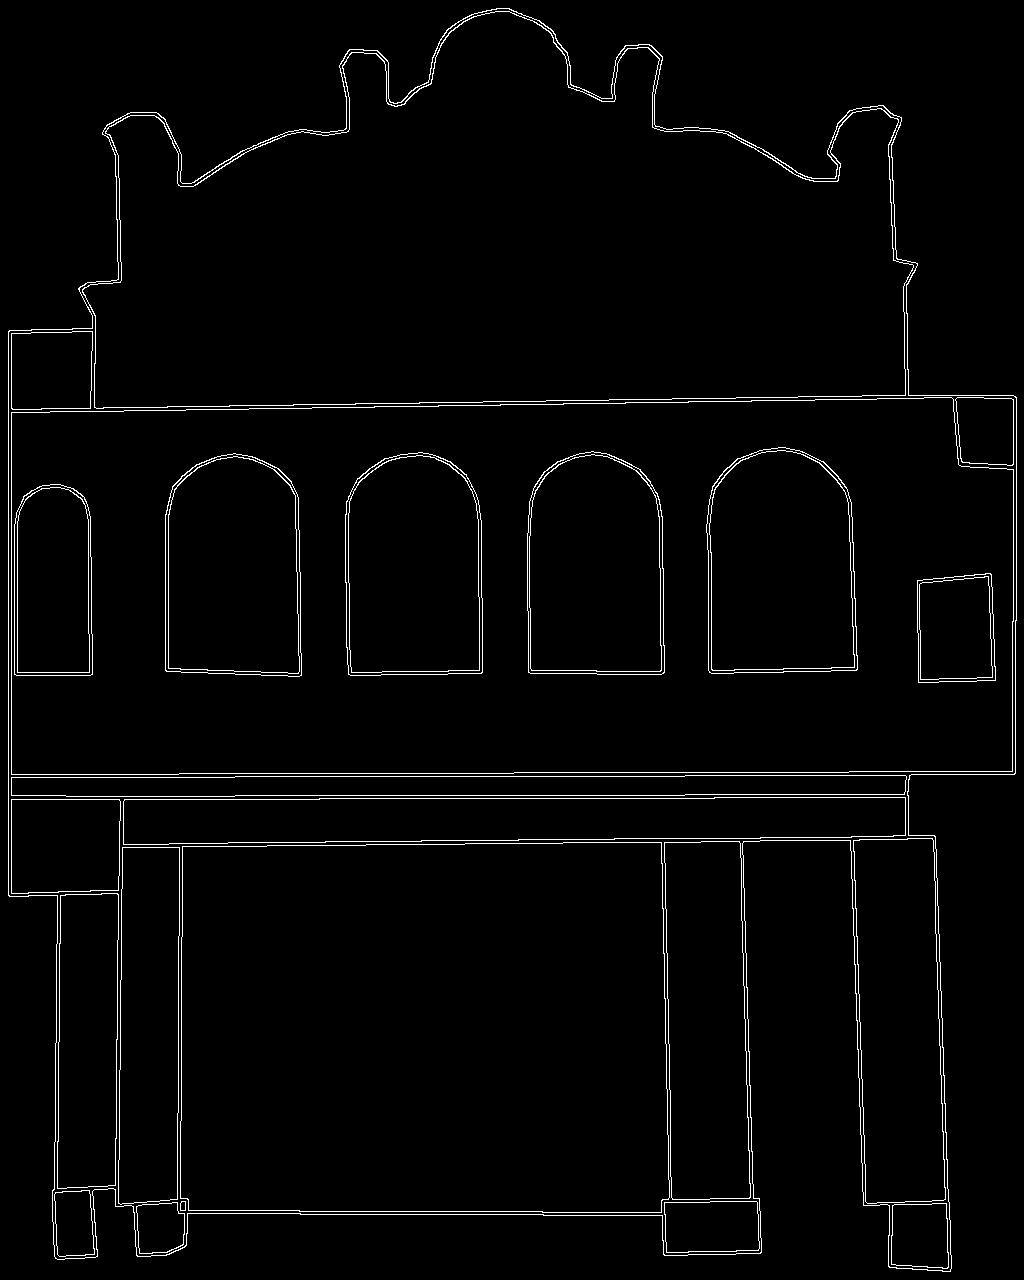

In [14]:
control_image

  0%|          | 0/20 [00:00<?, ?it/s]

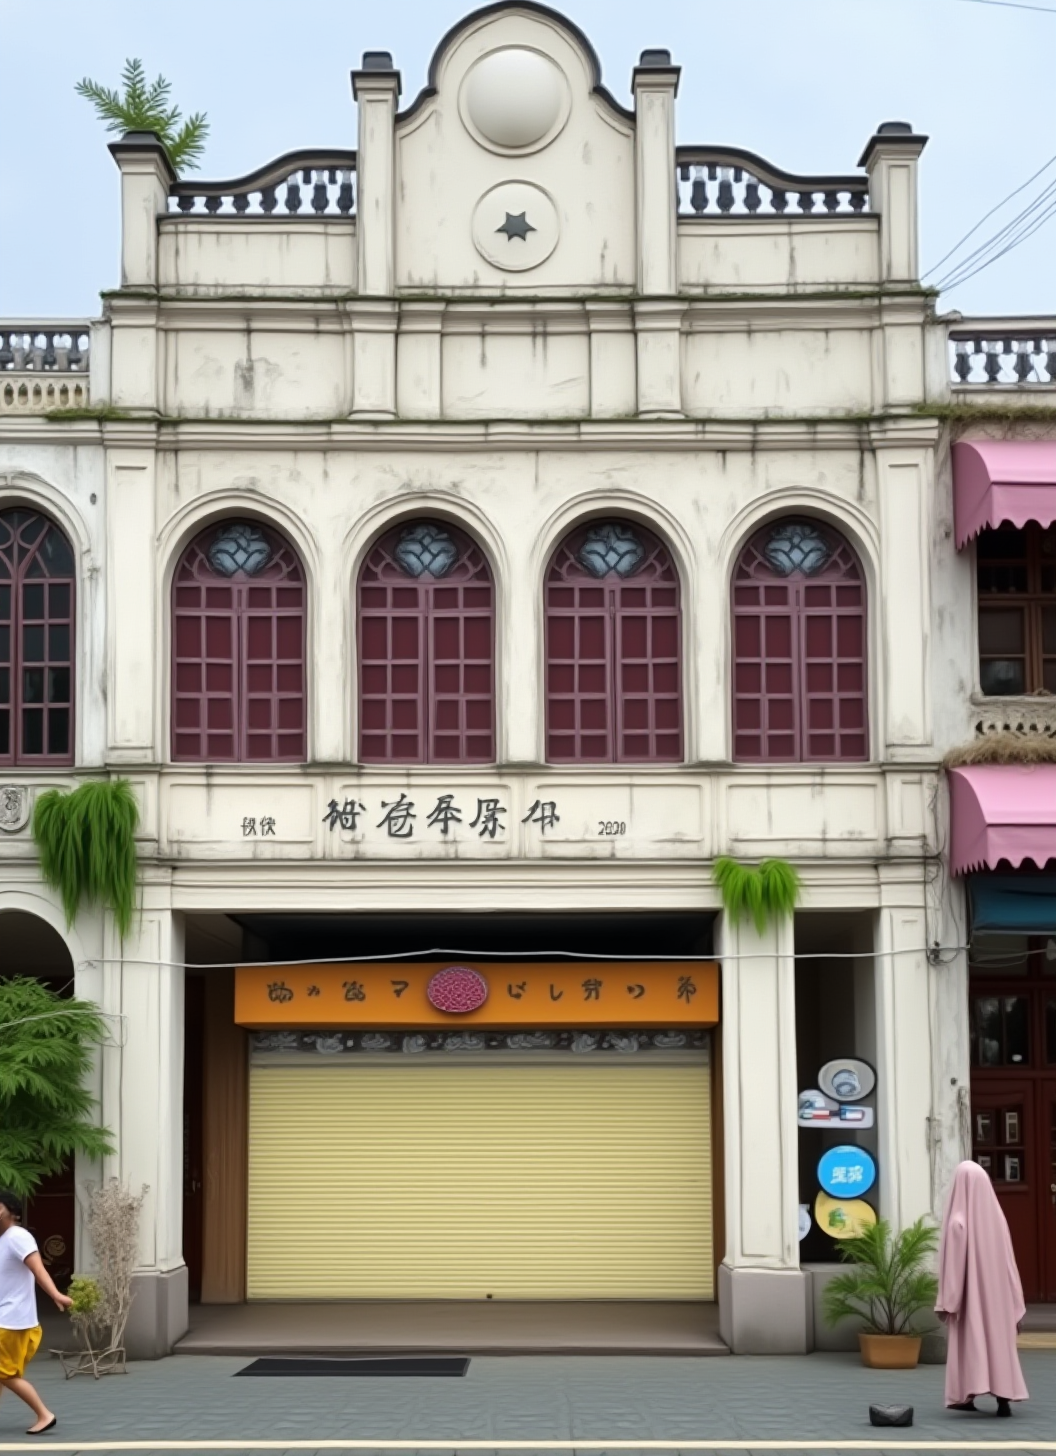

In [13]:
#prompt = '[architectural_heritage] an architectural heritage'
image_stage1 = generator.stage1(seed=111, global_style_image=global_style_image, control_image=control_image)
image_stage1